# Colorectal Cancer Tissue Classification with Deep Learning

This project explores several deep learning approaches for multiclass classification of colorectal cancer histology images from the PathMNIST dataset. We progressively compare increasingly complex architectures, starting from a dense neural network baseline, then moving to a convolutional neural network, transfer learning with ResNet-18, and finally a Vision Transformer. The objective is not only to obtain strong predictive performance, but also to understand the strengths, limitations, and interpretability of each method.

## Project overview

The goal of this project is to classify colorectal cancer histology patches into 9 tissue classes using the PathMNIST dataset. This dataset contains RGB images of size 28×28 extracted from histopathology slides. Since tissue classification is an important step in computational pathology, this task has both methodological and clinical relevance. In this notebook, we follow the progression requested in the project instructions, from a simple dense baseline to more advanced architectures such as convolutional networks, pretrained ResNet, and Vision Transformers. We also include an interpretability analysis using Grad-CAM in order to better understand which regions of the images drive the model predictions.

## Data and library importation

We begin by importing the required Python libraries for dataset handling, visualization, preprocessing, model training, and evaluation. The PathMNIST dataset is provided through the `medmnist` library, which offers a convenient way to access the train, validation, and test splits. At this stage, the goal is simply to prepare the environment and verify that all required tools are available before starting the analysis.

In [1]:
#pip install medmnist
from medmnist import PathMNIST

## 1. Data Exploration

Before training any model, it is essential to understand the structure and visual content of the dataset. In this section, we inspect the PathMNIST images, verify their dimensions, identify the class labels, and visualize representative samples from each tissue category. This preliminary exploration helps us better understand the classification problem and provides intuition about which classes may be visually easy or difficult to distinguish.

In [2]:
from medmnist import INFO
data_flag = "pathmnist"
info = INFO[data_flag]

print(info)

{'python_class': 'PathMNIST', 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.', 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1', 'MD5': 'a8b06965200029087d5bd730944a56c1', 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1', 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616', 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1', 'MD5_128': 

The PathMNIST dataset is already organized into training, validation, and test subsets. We load each split separately in order to respect a proper experimental protocol: the training set is used to optimize the model parameters, the validation set is used for model selection and hyperparameter tuning, and the test set is reserved for the final evaluation only.

In [3]:
train = PathMNIST(split="train", download=True)
val = PathMNIST(split="val", download=True)
test = PathMNIST(split="test", download=True)

# extract the images and labels from the datasets
train_images = train.imgs
train_labels = train.labels
val_images = val.imgs
val_labels = val.labels
test_images = test.imgs
test_labels = test.labels

We now inspect the dataset structure in more detail. In particular, we verify the image dimensions, the number of classes, and the label encoding. Since PathMNIST is a multiclass histology classification task with 9 tissue categories, understanding this structure is necessary before defining any neural network architecture.

In [4]:
# get image shape
train_images.shape

(89996, 28, 28, 3)

To better understand the visual diversity of the dataset, we display one representative image for each class. This first qualitative overview allows us to observe differences in color, texture, and tissue organization across categories such as adipose tissue, debris, lymphocytes, normal mucosa, and tumor epithelium. We have 9 classes '0' adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'

C:\Users\MANEL\AppData\Local\Temp\ipykernel_13296\854996401.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


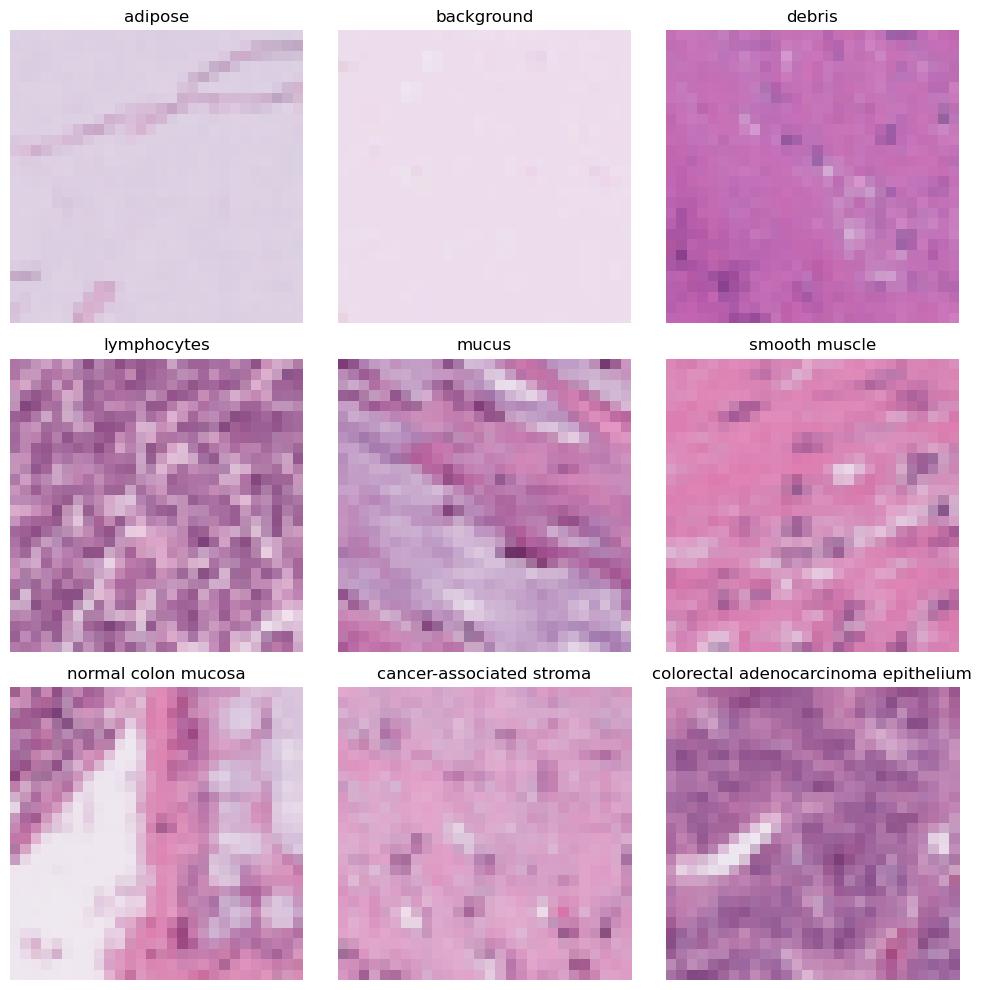

In [5]:

# Display one image per class
import matplotlib.pyplot as plt

num_classes = 9
class_images = [None] * num_classes
# find one image per class
for img, label in zip(train_images, train_labels):
    label = int(label)
    if class_images[label] is None:
        class_images[label] = img
    if all(x is not None for x in class_images):
        break

labels_names = info["label"]

# plot the images
plt.figure(figsize=(10,10))

for i in range(num_classes):
    plt.subplot(3,3,i+1)
    plt.imshow(class_images[i])
    plt.title(labels_names.get(str(i)))
    plt.axis("off")

plt.tight_layout()
plt.show()

The project instructions specifically ask us to compare the Debris and Background classes. This comparison is useful because some tissue categories may appear visually subtle at low resolution. By displaying several examples from both classes, we can identify characteristic differences in texture, color distribution, and structural organization.

C:\Users\MANEL\AppData\Local\Temp\ipykernel_13296\3835005171.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


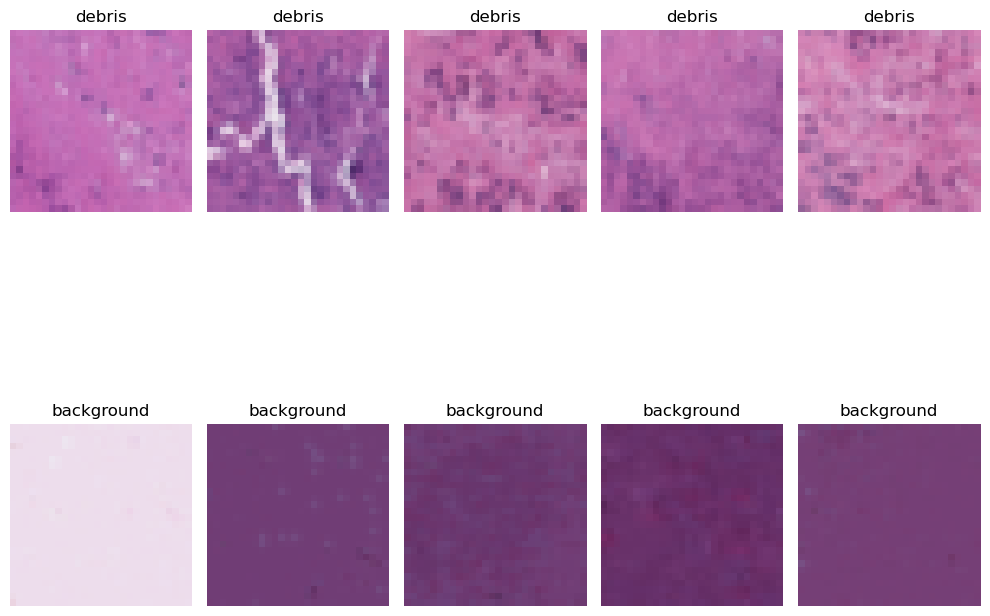

In [6]:
# look several images of the class "debris" and the class "background"
debris_images = []
background_images = []
i=0
j=0
for img, label in zip(train_images, train_labels):
    label = int(label)
    if label == 2:
        debris_images.append(img)
        i += 1
    elif label == 1:
        background_images.append(img)
        j += 1
    if i == 5 and j == 5:
        break
# plot the images
plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(debris_images[i])
    plt.title("debris")
    plt.axis("off")
for i in range(5):
    plt.subplot(2, 5, i+6)
    plt.imshow(background_images[i])
    plt.title("background")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Q1.1 – Visual comparison between Debris and Background

The Debris images tend to show more heterogeneous and irregular patterns than the Background images. In many debris samples, we can observe fragmented textures, denser local structures, and stronger color variation, often with darker purple or pink regions distributed unevenly across the patch. In contrast, the Background class generally appears more uniform, smoother, and visually emptier, with less structural content and weaker texture. Another noticeable difference is that debris often contains small clustered elements or tissue remnants, whereas background patches contain larger homogeneous areas with fewer meaningful visual details. Overall, debris seems more complex and textured, while background appears flatter and less informative.

To complement the visual exploration, we compute simple pixel statistics on one image from the training set. More precisely, we measure the mean and standard deviation for each RGB channel. These values help us quantify the image intensity distribution and allow us to compare it with commonly used normalization statistics such as those of ImageNet.

5


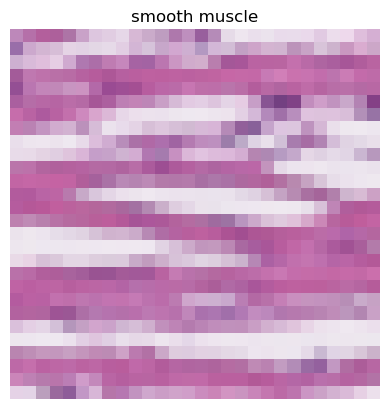

In [7]:
# pick any image from training dataset display it
import numpy as np
#pick an image
random_number = np.random.randint(0, len(train_images))
image_rdm = train_images[random_number]
label_rdm = train_labels[random_number]
print(label_rdm[0])
# display the image
plt.imshow(image_rdm)
plt.axis("off")
plt.title(labels_names.get(str(label_rdm[0])))
plt.show()

In [8]:
# report the pixel intensity statistics: mean and standard deviation per channel
means = np.mean(image_rdm, axis=(0,1))
stds = np.std(image_rdm, axis=(0,1))
print("Mean per channel:", means)
print("Standard deviation per channel:", stds)

Mean per channel: [198.22066327 147.55739796 189.88265306]
Standard deviation per channel: [23.35519939 49.1645433  29.7559633 ]


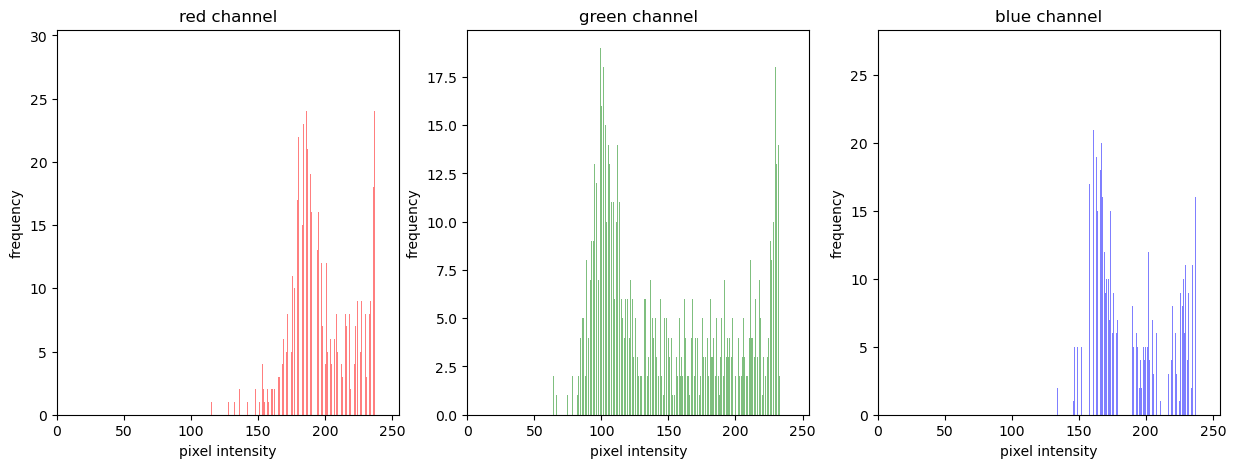

In [9]:
# plot the histogram of pixel intensities for each channel
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(image_rdm[:,:,0].flatten(), bins=256, color='red', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("red channel")
plt.subplot(1,3,2)
plt.hist(image_rdm[:,:,1].flatten(), bins=256, color='green', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("green channel")
plt.subplot(1,3,3)
plt.hist(image_rdm[:,:,2].flatten(), bins=256, color='blue', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("blue channel")
plt.show()

mean: [188.83897503 135.91045926 179.98635682]
std: [31.53896524 45.07444572 31.72982184]


Value with normalisation
mean normalized: [0.740545   0.53298219 0.70582885]
std normalized: [0.12368222 0.17676253 0.12443067]


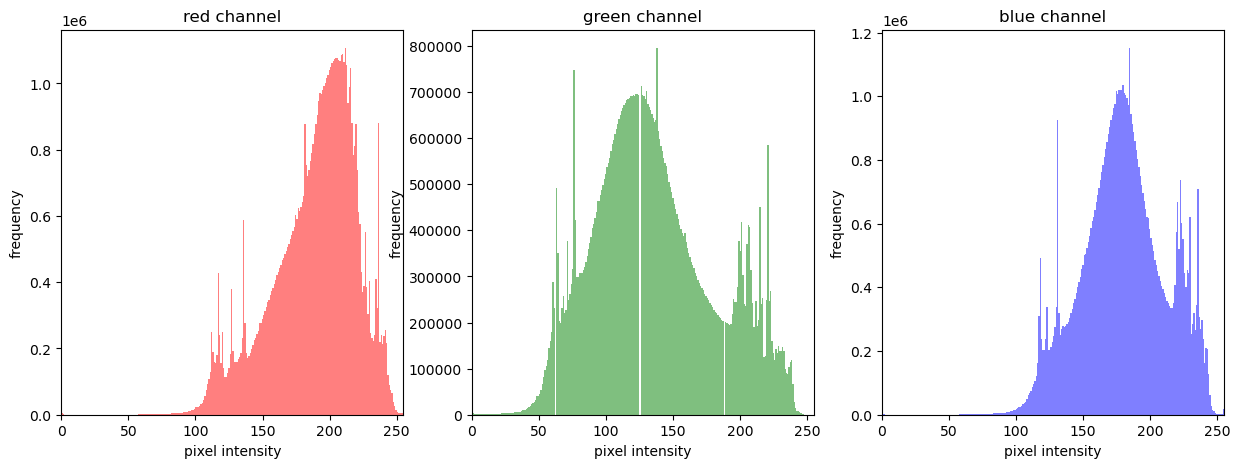

In [10]:
# generelyze for all the images in the training dataset.
mean = np.mean(train_images, axis=(0,1,2))
std = np.std(train_images, axis=(0,1,2))
print("mean:", mean)
print("std:", std)
mean_norm = mean / 255.0
std_norm = std / 255.0
print("\n")
print("Value with normalisation")
print("mean normalized:", mean_norm)
print("std normalized:", std_norm)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(train_images[:,:,:,0].flatten(), bins=256, color='red', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("red channel")
plt.subplot(1,3,2)
plt.hist(train_images[:,:,:,1].flatten(), bins=256, color='green', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("green channel")
plt.subplot(1,3,3)
plt.hist(train_images[:,:,:,2].flatten(), bins=256, color='blue', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("blue channel")
plt.show()

### Q1.2 – Pixel intensity statistics


The mean and standard deviation of pixel intensities were computed for a randomly selected training image. The obtained values were approximately mean = [188.8, 135.9, 180.0] and standard deviation = [31.5, 45.1, 31.7] in the [0,255] range. When rescaled to the [0,1] range, the mean values are around [0.74, 0.53, 0.71] and the standard deviations around [0.12, 0.18, 0.12]. These statistics differ from the commonly used normalization values derived from ImageNet (mean ≈ [0.485, 0.456, 0.406], std ≈ [0.229, 0.224, 0.225]). This difference is expected because histology images exhibit characteristic color distributions caused by hematoxylin–eosin staining, resulting in dominant pink and purple tones. Consequently, ImageNet normalization may not be optimal for this dataset, and it is preferable to compute dataset-specific statistics across the entire training set before training the convolutional neural network.

## 2) Dense Network

In this section, we implement a fully connected neural network (Multi-Layer Perceptron) to establish a baseline for the classification task.

Unlike convolutional neural networks, this model does not exploit the spatial structure of images. Instead, each image is flattened into a one-dimensional vector and processed through a sequence of dense layers.

The purpose of this baseline is to provide a reference point for evaluating more advanced architectures introduced later in the project.

The model is composed of multiple hidden layers with ReLU activations and includes dropout regularization to reduce overfitting.

### 2.1 Data Preparation

Before feeding the images into the dense network, we preprocess the data to ensure compatibility with the model.

Each image is normalized using statistics computed on the training set. Then, the images are flattened into vectors, as the MLP requires one-dimensional inputs.

The labels are also reshaped to match the expected format of the loss function.

We apply a normalization transform that converts images to tensors and standardizes each channel using the dataset-specific mean and standard deviation, ensuring that the input data is centered and scaled to improve training stability and convergence.

In [23]:
# Data preparation:
# Normalized data loaders
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# define the transformations for normalisation
transform_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_norm, std_norm)
])
# create the datasets with the transformations
train_ds_norm = PathMNIST(split='train', transform=transform_norm, download=True)
val_ds_norm = PathMNIST(split='val', transform=transform_norm, download=True)
test_dataset = PathMNIST(split='test', transform=transform_norm, download=True)

# create the data loaders
batch_size = 128
train_loader = DataLoader(train_ds_norm, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds_norm, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)



### 2.2 Training and evaluation utilities

Before defining the model itself, we implement reusable functions for training, validation, and evaluation. These utilities allow us to track the evolution of loss and accuracy over epochs, save the best validation model if needed, and compute performance metrics on the test set. Organizing the code in this way makes the experimental pipeline clearer and easier to reuse for the other architectures in the project.

In [12]:
# define train model function
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Confusion matrix function
def plot_confusion_matrix(model, data_loader, title="Confusion Matrix", labels_names=labels_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.squeeze().long().to(device)
            out = model(xb)
            all_preds.append(out.argmax(1).cpu())
            all_labels.append(yb.cpu())
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(16, 14))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names.values())
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
    ax.set_xticklabels(labels_names.values(), rotation=90, ha="center", fontsize = 14)
    ax.set_yticklabels(labels_names.values(), fontsize = 14)
    ax.set_title(title, fontsize=25)
    ax.set_xlabel('Predicted', fontsize=18)
    ax.set_ylabel('True', fontsize=18)
    plt.tight_layout()
    plt.show()

# define train model function
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, labels_names=labels_names):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # Training
        model.train()
        loss_sum, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb = xb.to(device) 
            yb = yb.squeeze().long().to(device)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(xb)
            correct += (out.argmax(1) == yb).sum().item()
            total += len(xb)
        history["train_loss"].append(loss_sum / total)
        history["train_acc"].append(correct / total)

        # Validation
        model.eval()
        loss_sum, correct, total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb= xb.to(device)
                yb = yb.squeeze().long().to(device)
                out = model(xb)
                loss = criterion(out, yb)
                loss_sum += loss.item() * len(xb)
                correct += (out.argmax(1) == yb).sum().item()
                total += len(xb)
        history["val_loss"].append(loss_sum / total)
        history["val_acc"].append(correct / total)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} — "
                  f"train_acc: {history['train_acc'][-1]:.3f}, "
                  f"val_acc: {history['val_acc'][-1]:.3f}")
            
    plot_confusion_matrix(
        model = model,
        data_loader = val_loader,
        title=f"Confusion Matrix",
        labels_names = labels_names
    )

    return history

Using device: cpu


We also define a visualization function to plot the training history. Displaying the evolution of training and validation loss and accuracy is important to assess convergence, detect overfitting, and compare models more effectively.

In [13]:
# create the function to plot the training history
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"],   label="Val")
    ax1.set_title(f"{title} — Loss"); ax1.legend()
    ax2.plot(history["train_acc"], label="Train")
    ax2.plot(history["val_acc"],   label="Val")
    ax2.set_title(f"{title} — Accuracy"); ax2.legend()
    plt.tight_layout(); plt.show()

### 2.3 Dense network architecture

We now define the dense baseline model. Following the project instructions, the architecture contains at least two hidden layers and dropout regularization. The hidden fully connected layers learn nonlinear combinations of pixel intensities, while the dropout layers help reduce overfitting by randomly deactivating a fraction of neurons during training. Even though this model does not explicitly exploit spatial information, it provides an essential baseline for the rest of the project.

In [ ]:
# define the MLP model from sratch with least 2 hidden layers and dropout
class DenseNetwork(nn.Module):
    """MLP with 2 hidden layers and dropout."""
    def __init__(self, input_dim=3*28*28, n_classes=num_classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)
# print the model summary
mlp_model = DenseNetwork()
print(mlp_model)


DenseNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=2352, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=9, bias=True)
  )
)


### 2.4 Training the dense baseline

We train the dense network on the PathMNIST training set and monitor its performance on the validation set across epochs. The objective here is to establish a first benchmark in terms of classification accuracy, validation loss, and confusion patterns. This baseline will later allow us to quantify the benefit of using convolutional architectures and transfer learning.

Training MLP model...
Epoch 5/30 — train_acc: 0.656, val_acc: 0.661
Epoch 10/30 — train_acc: 0.693, val_acc: 0.692
Epoch 15/30 — train_acc: 0.719, val_acc: 0.701
Epoch 20/30 — train_acc: 0.741, val_acc: 0.706
Epoch 25/30 — train_acc: 0.765, val_acc: 0.710
Epoch 30/30 — train_acc: 0.783, val_acc: 0.711


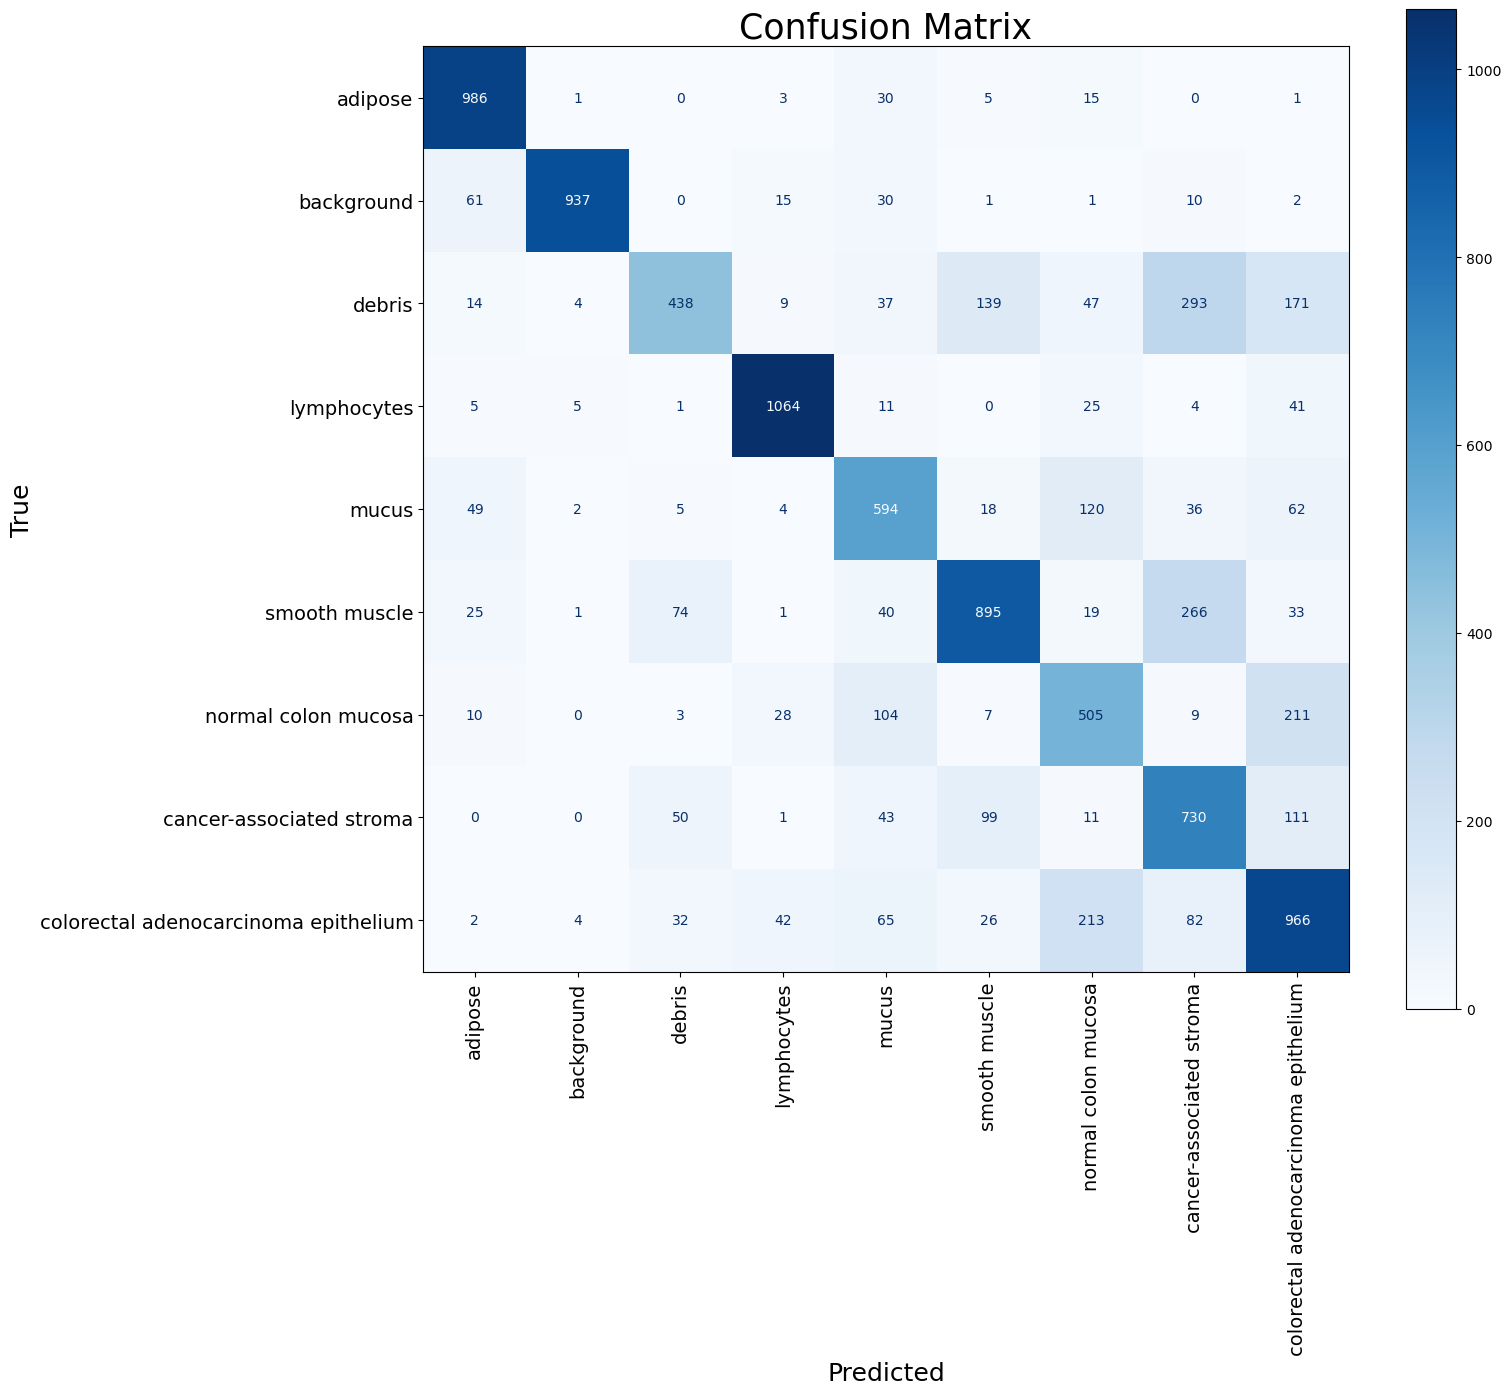

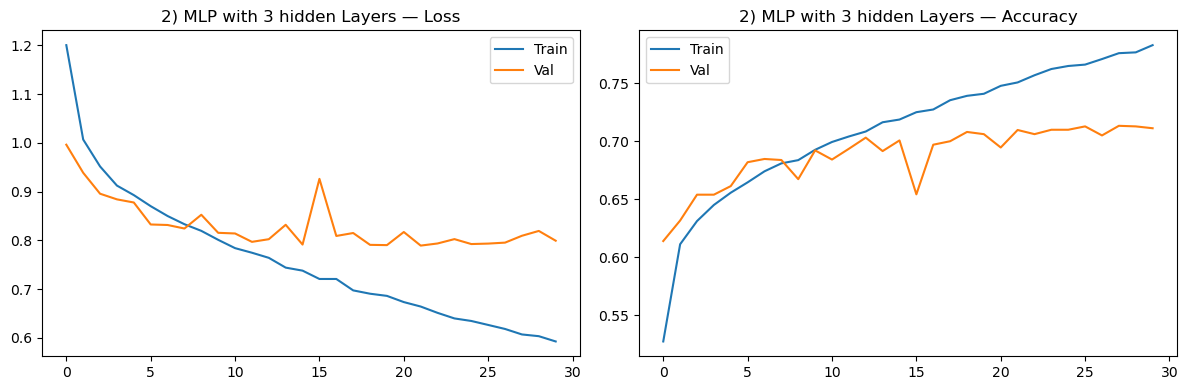

In [ ]:
print("Training MLP model...")
history_mlp = train_model(mlp_model, train_loader, val_loader, epochs=30, lr=1e-3, labels_names=labels_names)
plot_history(history_mlp, title="2) MLP with 3 hidden Layers")

### Q2.2 – Largest confusion in the matrix

The largest off-diagonal confusion occurs for the **Debris** class, which is frequently misclassified as **Cancer-Associated Stroma (293 samples)** and **Colorectal Adenocarcinoma Epithelium (171 samples)**. This indicates that the model struggles to distinguish debris from more structured pathological tissues.

This confusion is likely due to the visual similarity between these classes at low resolution (28×28 pixels). Debris often contains irregular textures and fragmented tissue components, which may resemble stromal or tumoral patterns when spatial details are limited. As a result, the model tends to associate these noisy or heterogeneous regions with biologically meaningful structures.

Another significant confusion appears between **Normal Colon Mucosa** and **Colorectal Adenocarcinoma Epithelium (211 samples)**. This is expected, as both classes share epithelial characteristics, and subtle morphological differences may not be well captured by the model.

These results highlight the limitations of the current architecture in capturing fine-grained histological patterns, especially for classes with overlapping visual features. This motivates the use of more advanced models, such as convolutional networks and transfer learning, which are better suited for extracting spatial and structural information.

### 2.5 Exact values requested in the instructions

Q.1) The project instructions require the exact test accuracy and the exact validation loss at epoch 1, epoch 10, and the final epoch. We therefore extract these values directly from the training logs instead of rounding them, so that the notebook answers the question precisely and transparently.

In [16]:
print("===== REPORT VALUES =====")
print("Exact values of the validation loss at epoch 1, epoch 10 and the final epoch.")
print(f"Epoch 1  - val_loss: {history_mlp['val_loss'][0]}")
print(f"Epoch 10 - val_loss: {history_mlp['val_loss'][9]}")
print(f"Final epoch ({len(history_mlp['val_loss'])}) - val_loss: {history_mlp['val_loss'][-1]}")
print("Exact values of the validation accuracy at the same epochs.")
print(f"Epoch 1  - val_acc: {history_mlp['val_acc'][0]}")
print(f"Epoch 10 - val_acc: {history_mlp['val_acc'][9]}")
print(f"Final epoch ({len(history_mlp['val_acc'])}) - val_acc: {history_mlp['val_acc'][-1]}")

===== REPORT VALUES =====
Exact values of the validation loss at epoch 1, epoch 10 and the final epoch.
Epoch 1  - val_loss: 0.9964279617275633
Epoch 10 - val_loss: 0.8156707793271623
Final epoch (30) - val_loss: 0.7994548520866465
Exact values of the validation accuracy at the same epochs.
Epoch 1  - val_acc: 0.6139544182327069
Epoch 10 - val_acc: 0.6921231507397041
Final epoch (30) - val_acc: 0.7112155137944822


Between epoch 1 and epoch 10, the model shows a significant improvement, with the validation loss decreasing from 0.996 to 0.816 and the validation accuracy increasing from 61.4% to 69.2%. However, between epoch 10 and the final epoch (30), the improvement becomes much smaller, with the validation loss only slightly decreasing to 0.799 and the validation accuracy reaching 71.1%. This suggests that the model starts to converge after around 10 epochs, with diminishing returns from additional training.

## 3. CNN from Scratch

After establishing a dense baseline, we move to a convolutional neural network. Unlike a multilayer perceptron, a CNN preserves the spatial organization of the image and learns local patterns through convolutional filters. This makes CNNs particularly well suited for histology images, where texture, shape, and spatial arrangement are essential for distinguishing tissue types. In this part, we design a regularized CNN with multiple convolutional blocks, batch normalization, dropout, and data augmentation.

We define a convolutional neural network composed of three successive convolutional blocks with batch normalization, ReLU activations, max pooling, and dropout for regularization, followed by a fully connected classifier that maps the extracted spatial features to the final tissue class predictions.

In [17]:
class CNNFromScratch(nn.Module):
    """CNN with 3 conv blocks, batch norm, and dropout."""
    def __init__(self, n_classes=num_classes):
        super().__init__()
        # Block 1: 3 -> 32
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        # Block 2: 32 -> 64
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        # Block 3: 64 -> 128
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

In [ ]:
cnn_model = CNNFromScratch(n_classes=num_classes).to(device)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

Total trainable parameters: 437,545


In [21]:
print("===== CNN FROM SCRATCH STRUCTURE =====")
cnn_model

===== CNN FROM SCRATCH STRUCTURE =====


CNNFromScratch(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   

This convolutional neural network is structured into three hierarchical convolutional blocks with increasing channel depth (from 32 to 128), each combining convolution, batch normalization, ReLU activation, max pooling, and dropout to progressively extract and regularize spatial features, followed by a fully connected classifier that maps the learned representations to the final class predictions.

In [ ]:
print(f"Total trainable parameters: {total_params:,}")

The model contains a total of 437,545 trainable parameters, which reflects a moderate level of complexity: it is sufficiently expressive to capture relevant spatial patterns in the data, while remaining computationally efficient and less prone to overfitting compared to larger architectures.

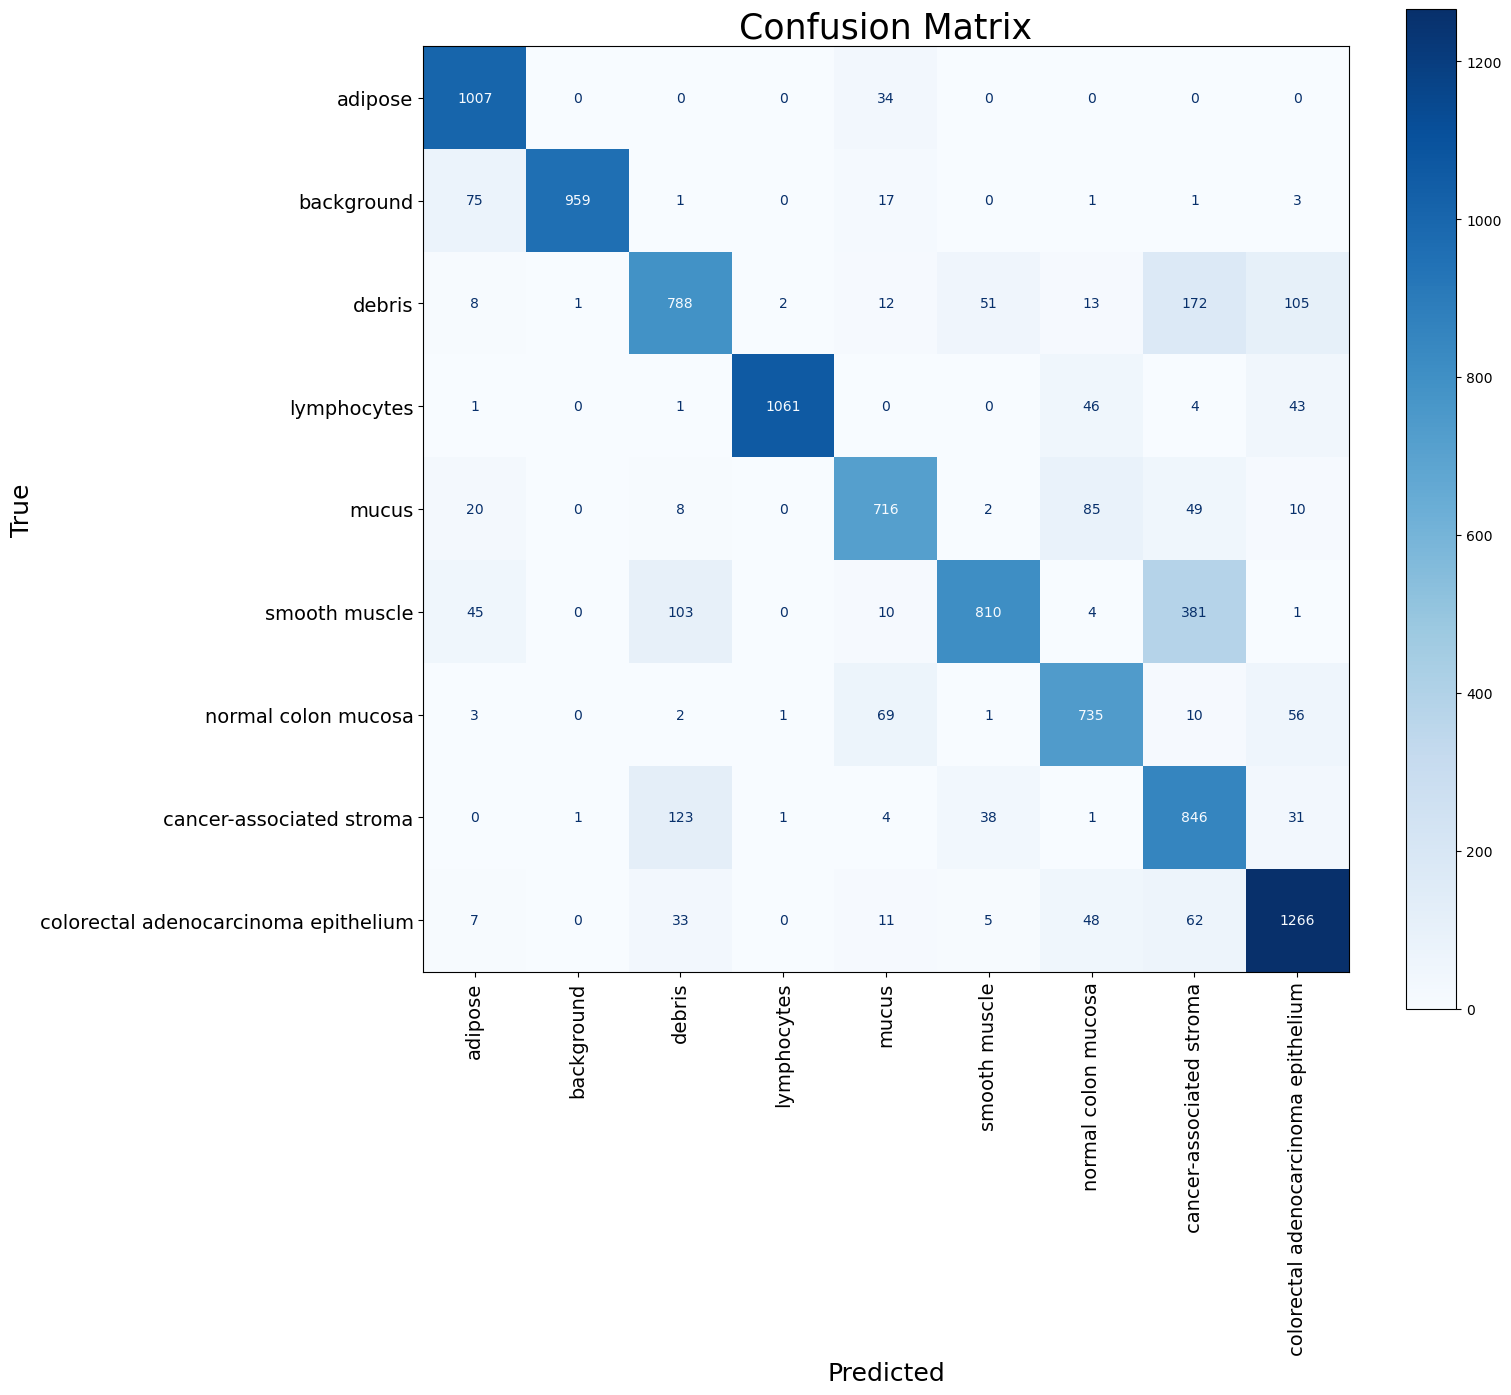

In [24]:
cnn_noaug = CNNFromScratch(n_classes=num_classes).to(device)
optimizer_cnn_noaug = optim.Adam(cnn_noaug.parameters(), lr=1e-3)
history_cnn_noaug = train_model(cnn_noaug, train_loader, val_loader, epochs=1, lr=1e-3, labels_names=labels_names)
